---
title: "03 — Operators on Sentinel-2 (Lake Tahoe NDVI)"
---

# Composing a Sentinel-2 NDVI pipeline

This notebook is the **operator-composition slice** of the canonical
Lake Tahoe scenario: cloud-free Sentinel-2 NDVI over Lake Tahoe, summer
2024. The end-to-end multi-repo flow (catalog discovery → patching →
operators) lives in
[`geocatalog/docs/notebooks/end_to_end_lake_tahoe.ipynb`](https://github.com/jejjohnson/geocatalog/blob/main/docs/notebooks/end_to_end_lake_tahoe.ipynb).
Here we focus on the `geotoolz` part: composing **named operators**
from `gz.radiometry`, `gz.indices`, `gz.cloud`, and `gz.mask` into
linear and DAG-shaped pipelines.

**Scenario.**

| | |
|---|---|
| AOI bbox (EPSG:4326) | `(-120.10, 38.92, -119.93, 39.27)` (Lake Tahoe main body) |
| Date range | `2024-06-01` to `2024-07-15` (peak-green Sierra window) |
| STAC | Microsoft Planetary Computer (`planetarycomputer.microsoft.com/api/stac/v1`) |
| Collection | `sentinel-2-l2a` |
| MGRS tile | `10SGJ` (fully covers the AOI; the other candidate `11SKD` only clips a sliver) |
| Cloud cover | < 5 % |

The named operators we use:

| Step | Operator | From |
|---|---|---|
| DN → reflectance | `DNToReflectance(scale=1e-4)` | `gz.radiometry` |
| Percentile stretch for the RGB preview | `PercentileClip(p_min=2, p_max=98)` | `gz.radiometry` |
| NDVI | `NDVI(red_idx=2, nir_idx=3)` | `gz.indices` |
| NDWI (water/vegetation complement) | `NDWI(green_idx=1, nir_idx=3)` | `gz.indices` |
| Cloud-class mask from SCL | `MaskFromSCL(classes=SCL_CLOUDS_AND_INVALID)` | `gz.cloud` |
| Drop masked pixels | `ApplyMask(mask=..., fill_value=np.nan)` | `gz.mask` |

When you need to write a *new* operator that does not yet live in
`geotoolz`, the [Define an operator](https://github.com/jejjohnson/geotoolz/blob/main/docs/recipes/define-an-operator.md)
recipe walks through the contract.

## 1. Load one Sentinel-2 scene via Microsoft Planetary Computer

We use `pystac-client` to find one low-cloud scene in the AOI / date
range, then `rioxarray` to load three bands: B04 (Red, 10 m), B08 (NIR,
10 m), and the SCL scene-classification band (20 m, resampled to the
10 m grid with nearest-neighbour). Red + NIR go into one carrier
`rn_gt` (the reflectance pipeline input); SCL goes into a separate
carrier `scl_gt` (the cloud-mask source).

In [1]:
import geotoolz as gz
import matplotlib.pyplot as plt
import numpy as np
import planetary_computer
import pystac_client
import rioxarray
import xarray as xr
from georeader.geotensor import GeoTensor
from geotoolz.cloud import SCL_CLOUDS_AND_INVALID
from rasterio.enums import Resampling

In [2]:
BBOX = (-120.10, 38.92, -119.93, 39.27)  # Lake Tahoe main body
# Peak-green window: post-snowmelt, pre-summer-drought. September Sierra
# scenes are technically cloud-free too but the vegetation is heat-
# stressed and NDVI plots wash out into orange.
DATE_RANGE = "2024-06-01/2024-07-15"
TARGET_TILE = "10SGJ"  # fully covers the AOI

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=BBOX,
    datetime=DATE_RANGE,
    query={
        "eo:cloud_cover": {"lt": 5},
        "s2:mgrs_tile": {"eq": TARGET_TILE},
    },
)
items = sorted(search.items(), key=lambda x: x.properties["eo:cloud_cover"])
print(f"found {len(items)} candidate items on tile {TARGET_TILE}")
item = items[0]
print(f"using {item.id}  cloud_cover={item.properties['eo:cloud_cover']:.1f}%")

found 17 candidate items on tile 10SGJ
using S2B_MSIL2A_20240614T183919_R070_T10SGJ_20240615T003207  cloud_cover=0.0%


In [3]:
def _load(
    asset_key: str,
    *,
    resample_to: xr.DataArray | None = None,
    resampling: Resampling = Resampling.bilinear,
) -> xr.DataArray:
    href = item.assets[asset_key].href
    da = rioxarray.open_rasterio(href, masked=False).squeeze("band", drop=True)
    da = da.rio.clip_box(*BBOX, crs="EPSG:4326")
    if resample_to is not None:
        da = da.rio.reproject_match(resample_to, resampling=resampling)
    return da


red = _load("B04")
green = _load("B03", resample_to=red)
blue = _load("B02", resample_to=red)
nir = _load("B08", resample_to=red)
scl = _load("SCL", resample_to=red, resampling=Resampling.nearest)

# Four-band reflectance carrier — B (idx 0), G (1), R (2), NIR (3) —
# uint16 DN values. Standard BGRN stacking; B04 → idx 2, B08 → idx 3.
bgrn_arr = np.stack([blue.values, green.values, red.values, nir.values], axis=0).astype(
    "uint16"
)
bgrn_gt = GeoTensor(
    values=bgrn_arr,
    transform=red.rio.transform(),
    crs=red.rio.crs,
    fill_value_default=0,
)

# Separate SCL carrier (1, H, W).
scl_gt = GeoTensor(
    values=scl.values[None, ...].astype("uint8"),
    transform=scl.rio.transform(),
    crs=scl.rio.crs,
    fill_value_default=0,
)

print(f"bgrn_gt: shape={bgrn_gt.shape}  dtype={bgrn_gt.dtype}")
print(f"scl_gt:  shape={scl_gt.shape}  dtype={scl_gt.dtype}")

bgrn_gt: shape=(4, 3935, 1599)  dtype=uint16
scl_gt:  shape=(1, 3935, 1599)  dtype=uint8


## 2. True-color reference

Before running the index, plot a percentile-stretched true-color
composite so we know what the scene looks like. `gz.radiometry.PercentileClip`
is the named op for the stretch; `np.transpose` reorders (C, H, W) →
(H, W, C) for matplotlib.

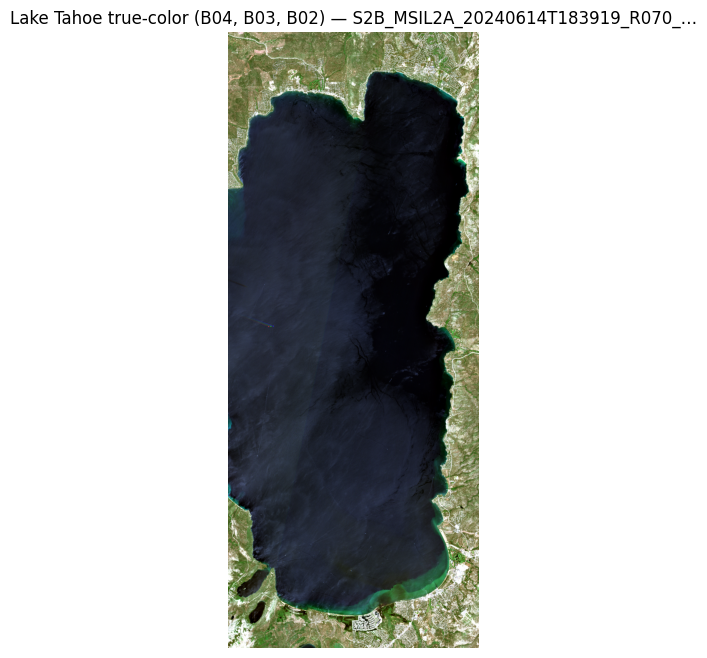

In [4]:
rgb_pipe = gz.radiometry.DNToReflectance(scale=1e-4) | gz.radiometry.PercentileClip(
    p_min=2.0, p_max=98.0
)
rgb_full = rgb_pipe(bgrn_gt)
rgb_arr = np.asarray(rgb_full)[[2, 1, 0]]  # R, G, B from B-G-R-NIR

fig, ax = plt.subplots(figsize=(7, 8))
ax.imshow(np.transpose(rgb_arr, (1, 2, 0)))
ax.set_title(f"Lake Tahoe true-color (B04, B03, B02) — {item.id[:32]}…")
ax.axis("off")
plt.show()

## 3. Compose NDVI with `Sequential`

The simplest possible shape — DN → reflectance, then NDVI. Two named
ops, one `|`. BGRN stack → red is at idx 2, NIR at idx 3.

In [5]:
pipe = gz.radiometry.DNToReflectance(scale=1e-4) | gz.indices.NDVI(red_idx=2, nir_idx=3)
print(pipe)
ndvi_gt = pipe(bgrn_gt)
print("ndvi shape:", ndvi_gt.shape)
print(
    "ndvi range:",
    float(np.nanmin(np.asarray(ndvi_gt))),
    float(np.nanmax(np.asarray(ndvi_gt))),
)

Sequential([DNToReflectance(scale=0.0001, offset=0.0, axis=0), NDVI(nir_idx=3, red_idx=2, axis=0, eps=1e-10)])
ndvi shape: (3935, 1599)
ndvi range: -0.9999999992647058 0.999999999057493


## 4. Visualise the raw NDVI

Standard NDVI ramp. We use `RdYlGn` clipped at `vmin=-0.4, vmax=0.9`
so water shows red, conifer forest shows green, and the dry granite
/ scrub middle ground reads as a transition rather than alarming
orange.

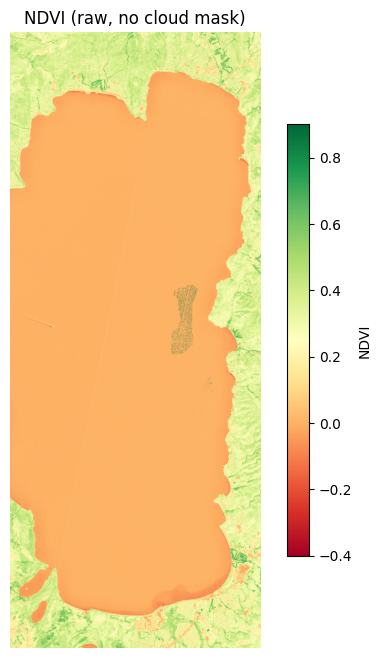

In [6]:
fig, ax = plt.subplots(figsize=(7, 8))
im = ax.imshow(np.asarray(ndvi_gt), cmap="RdYlGn", vmin=-0.4, vmax=0.9)
ax.set_title("NDVI (raw, no cloud mask)")
ax.axis("off")
fig.colorbar(im, ax=ax, shrink=0.7, label="NDVI")
plt.show()

## 5. Cloud-aware variant

We extract a "drop these pixels" mask from SCL using
[`gz.cloud.MaskFromSCL`](https://github.com/jejjohnson/geotoolz/blob/main/docs/api/cloud.md), then attach
[`gz.mask.ApplyMask`](https://github.com/jejjohnson/geotoolz/blob/main/docs/api/mask.md) at the end of the same `Sequential`.
The mask is True on cloud + invalid pixels; `ApplyMask` follows the
library convention ("True = drop") so the call is just
`ApplyMask(mask=cloud_mask, fill_value=np.nan)`.

In [7]:
cloud_op = gz.cloud.MaskFromSCL(
    band_idx=0,
    classes=SCL_CLOUDS_AND_INVALID,
)
cloud_mask = cloud_op(scl_gt)
print("cloud_mask shape:", cloud_mask.shape, "dtype:", cloud_mask.dtype)
print(f"fraction masked: {float(np.mean(np.asarray(cloud_mask))):.3f}")

clean_pipe = (
    gz.radiometry.DNToReflectance(scale=1e-4)
    | gz.indices.NDVI(red_idx=2, nir_idx=3)
    | gz.mask.ApplyMask(mask=cloud_mask, fill_value=float("nan"))
)
print(clean_pipe)
ndvi_clean = clean_pipe(bgrn_gt)
print(
    "clean ndvi range:",
    float(np.nanmin(np.asarray(ndvi_clean))),
    float(np.nanmax(np.asarray(ndvi_clean))),
)

cloud_mask shape: (3935, 1599) dtype: bool
fraction masked: 0.000
Sequential([DNToReflectance(scale=0.0001, offset=0.0, axis=0), NDVI(nir_idx=3, red_idx=2, axis=0, eps=1e-10), ApplyMask(mask={'type': 'ndarray', 'shape': [3935, 1599], 'dtype': 'bool'}, fill_value=nan, invert=False)])
clean ndvi range: -0.9999999992647058 0.999999999057493


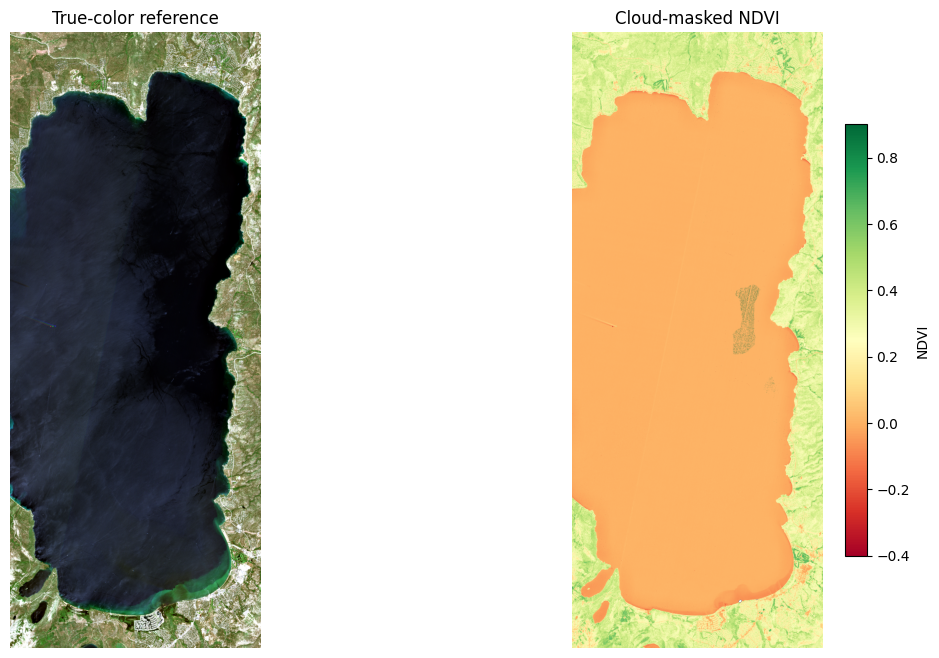

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 8))
ax1.imshow(np.transpose(rgb_arr, (1, 2, 0)))
ax1.set_title("True-color reference")
ax1.axis("off")
im2 = ax2.imshow(np.asarray(ndvi_clean), cmap="RdYlGn", vmin=-0.4, vmax=0.9)
ax2.set_title("Cloud-masked NDVI")
ax2.axis("off")
fig.colorbar(im2, ax=ax2, shrink=0.7, label="NDVI")
plt.show()

## 6. Fan-out — multiple indices from one scaled scene

`gz.Fanout` is sugar over a single-input `Graph`: one input, many named
outputs. Here we compute NDVI and `NDWI` (the water-detection
complement; high over open water, low over vegetation) off the same
reflectance carrier — water and vegetation light up in opposite
panels.

In [9]:
scaled = gz.radiometry.DNToReflectance(scale=1e-4)(bgrn_gt)
products = gz.Fanout(
    {
        "ndvi": gz.indices.NDVI(red_idx=2, nir_idx=3),
        "ndwi": gz.indices.NDWI(green_idx=1, nir_idx=3),
    }
)(scaled)
print("product keys:", list(products.keys()))
print("ndvi shape:", products["ndvi"].shape)
print("ndwi shape:", products["ndwi"].shape)

product keys: ['ndvi', 'ndwi']
ndvi shape: (3935, 1599)
ndwi shape: (3935, 1599)


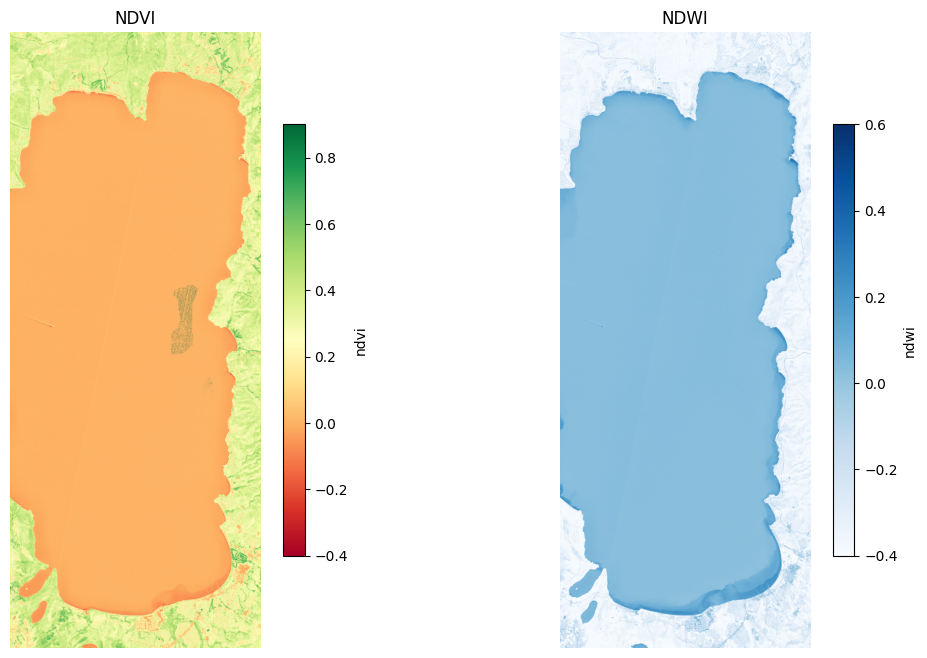

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 8))
cfg = [("ndvi", "RdYlGn", (-0.4, 0.9)), ("ndwi", "Blues", (-0.4, 0.6))]
for ax, (name, cmap, (vmin, vmax)) in zip(axes, cfg, strict=True):
    im = ax.imshow(np.asarray(products[name]), cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(name.upper())
    ax.axis("off")
    fig.colorbar(im, ax=ax, shrink=0.7, label=name)
plt.show()

## 7. Observability — inspect, time, assert

`Operator` is general enough that *side-effects* round-trip the same
as transforms. pipekit ships a small library of identity-with-side-
effect ops you compose inline:

| Primitive | Role | Re-exported as |
|---|---|---|
| `Tap(fn, name=...)` | callback hook (logging / breakpoints) | `gz.Tap` |
| `ShapeTrace(mode="diff_only")` | log `shape`/`dtype` on change | `gz.ShapeTrace` |
| `Snapshot()` + `snap.at(key)` | capture intermediates by key | `gz.Snapshot` |
| `Profile()` + `prof.wrap(op)` | per-step wall-clock | `from pipekit import Profile` |
| `AssertShape(expected)` | runtime contract; raises `QCError` | `from pipekit import AssertShape` |
| `AssertDType(expected)` | runtime dtype contract | `from pipekit import AssertDType` |
| `Quarantine(check, sentinel)` | non-raising QC (route bad inputs) | `from pipekit import Quarantine` |

None of these change the pipeline output — they just observe or
enforce. Drop them in with `|`, take them out for production.

In [11]:
from pipekit import AssertDType, AssertShape, Profile


snap = gz.Snapshot()
prof = Profile()

# Same NDVI pipeline as §3, but instrumented:
#   - AssertShape pins the input contract (4 bands, any H × W)
#   - Tap logs the dtype on the first call
#   - Snapshot.at captures the reflectance intermediate by key
#   - ShapeTrace prints when shape/dtype changes between steps
#   - Profile.wrap times each operator
#   - AssertDType pins the output contract
trace = gz.ShapeTrace(mode="diff_only", label="ndvi")

observed = (
    AssertShape((4, None, None))
    | gz.Tap(lambda gt: print(f"input dtype: {np.asarray(gt).dtype}"), name="log_dtype")
    | prof.wrap(gz.radiometry.DNToReflectance(scale=1e-4))
    | snap.at("reflectance")
    | trace
    | prof.wrap(gz.indices.NDVI(red_idx=2, nir_idx=3))
    | trace
    | AssertDType("float64")
)
_ = observed(bgrn_gt)

print("\nSnapshot keys:", list(snap.captures))
print(
    "reflectance carrier:",
    snap.captures["reflectance"].shape,
    snap.captures["reflectance"].dtype,
)
print("\nProfile report:")
for name, stats in prof.report().items():
    print(
        f"  {name:20s}  calls={int(stats['calls'])}  mean={stats['mean'] * 1000:6.1f} ms"
    )

input dtype: uint16
[ndvi] shape=(4, 3935, 1599) dtype=float64
[ndvi] shape=(3935, 1599) dtype=float64

Snapshot keys: ['reflectance']
reflectance carrier: (4, 3935, 1599) float64

Profile report:
  DNToReflectance       calls=1  mean=  32.9 ms
  NDVI                  calls=1  mean=  17.2 ms


What you'd reach for next:

- **`Quarantine`** — route bad-cloud-fraction scenes to a sentinel
  instead of aborting the batch.
- **`Cache`** — memoize by config + input hash for expensive ops
  (Ledoit-Wolf covariance, learned models).
- **`Try` / `Coalesce` / `Retry`** — production control flow for
  flaky external loaders (STAC, S3).

Each is itself an `Operator` so the whole stack composes uniformly.

## 8. When to use which composition primitive

The cells above used `Sequential` (linear) and `Fanout` (one input,
many outputs). The choice tree for the rest:

| You want… | Reach for | Why |
|---|---|---|
| A linear chain of 2–6 ops | `Sequential` (or `op_a \| op_b`) | Smallest API surface; flattens nested pipes. |
| Named intermediates / branching / fan-in | `Graph` | Same scene, multiple sub-pipelines, fused at the end. |
| Runtime two-way fork (e.g. reproject if geographic) | `Branch` | Predicate evaluates the whole carrier. |
| Sensor / product dispatch (`'S2'` vs `'L8'`) | `Switch` | Finite named cases; default is `Identity`. |
| One input → many named derived products | `Fanout` | Sugar over a single-input `Graph`. |

Each of these is itself an `Operator`, so they nest freely: a `Graph`
inside a `Sequential`, a `Switch` whose cases are `Sequential`s, a
`Fanout` whose values are `Graph`s.

## 8. Where next

- **End-to-end Lake Tahoe (cross-repo):** the canonical multi-package
  walkthrough lives in
  [`geocatalog/docs/notebooks/end_to_end_lake_tahoe.ipynb`](https://github.com/jejjohnson/geocatalog/blob/main/docs/notebooks/end_to_end_lake_tahoe.ipynb)
  — STAC discovery → catalog loading → patching → operators.
- **Define your own operator:** when something is not in the named-op
  surface yet, write a subclass — see
  [Define an operator](https://github.com/jejjohnson/geotoolz/blob/main/docs/recipes/define-an-operator.md).
- **More composition patterns:** the
  [pipeline idioms notebook](02_pipeline_idioms.ipynb) is a recipe gallery
  of observer / control-flow / QC patterns.
- **Deployment shapes:** the
  [deployment shapes notebook](07_deployment_shapes.ipynb) tours 13
  deployment patterns (notebook, ETL, FastAPI, tile server, …).
- **Concepts:** the [Concepts page](https://github.com/jejjohnson/geotoolz/blob/main/docs/concepts.md) explains the model
  behind these primitives with diagrams.
- **Recipes:** [Branching pipelines](https://github.com/jejjohnson/geotoolz/blob/main/docs/recipes/branching-pipelines.md),
  [Integration with geocatalog & geopatcher](https://github.com/jejjohnson/geotoolz/blob/main/docs/recipes/integration-with-geocatalog-and-geopatcher.md).